# Sales Data Cleaning & Exploratory Analysis

**Goal:** Clean a messy e-commerce sales export and answer concrete
business questions about revenue, customers, and operations.

**Dataset:** 486 orders for a fictional online clothing store, covering
three months (Jun-Aug 2026). It is a **simulated dataset**, built to mimic
the kind of inconsistencies a real operations export actually has: mixed
date formats, mixed Arabic/English city names, currency-labeled price
strings, inconsistent phone formats, and duplicate rows. The business
figures below are illustrations of the analysis, not findings about a real
store.

**Pipeline:** `Raw Data -> Cleaning -> EDA -> Visualization -> Excel report`


In [1]:
import sys
sys.path.insert(0, "../src")

import pandas as pd
import matplotlib.pyplot as plt
from cleaning import load_and_clean

pd.set_option("display.max_columns", None)


## 1. Data Audit — what was actually wrong

Before writing any cleaning code, the raw file was profiled to find every
issue rather than guessing:


In [2]:
raw = pd.read_excel("../data/raw/messy_sales_data.xlsx", sheet_name="Sales")
print("Shape:", raw.shape)
print("\nMissing values per column:")
print(raw.isnull().sum())
print("\nFully duplicated rows:", raw.duplicated().sum())


Shape: (486, 11)

Missing values per column:
Order ID           0
Order Date         0
Customer Name      3
Phone             26
City              15
Product            0
Category           0
Qty                4
Price             17
Payment Method     0
Status             0
dtype: int64

Fully duplicated rows: 36


**Issues found:**

| Column | Problem |
|---|---|
| `Order Date` | 5+ mixed formats (ISO, `D/M/Y`, `D-Mon-Y`, dotted `D.M.Y`/`M.D.Y`, and native datetime objects). The dotted format is genuinely ambiguous for some rows (e.g. `04.07.2026`); see the note below. |
| `City` | Same city written in Arabic and English, mixed case, abbreviations, and a `'-'` placeholder |
| `Price` | Numbers mixed with currency-labeled strings (`'EGP 950'`, `'950 جنيه'`, `'1,100'`) |
| `Phone` | Local format, `+20` country code, numbers that lost their leading zero, `'-'` placeholder |
| `Product` | Same product in different casing/spacing (e.g. `Tshirt` vs `T-Shirt`) |
| *(all rows)* | 36 fully duplicated rows |


In [3]:
df = load_and_clean("../data/raw/messy_sales_data.xlsx")
print("Rows before cleaning:", len(raw), " | after cleaning + dedup:", len(df))
df.info()


Rows before cleaning: 486  | after cleaning + dedup: 450
<class 'pandas.DataFrame'>
Index: 450 entries, 0 to 485
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Order ID        450 non-null    int64         
 1   Order Date      450 non-null    datetime64[us]
 2   Customer Name   450 non-null    str           
 3   Phone           450 non-null    str           
 4   City            430 non-null    str           
 5   Product         450 non-null    str           
 6   Category        450 non-null    str           
 7   Qty             445 non-null    float64       
 8   Price           428 non-null    float64       
 9   Payment Method  450 non-null    str           
 10  Status          450 non-null    str           
 11  Month           450 non-null    period[M]     
 12  Revenue         425 non-null    float64       
dtypes: datetime64[us](1), float64(3), int64(1), period[M](1), str(7)
memo

**Note on the dotted date format:** a value like `04.07.2026` can be read as
either 4 July or 4 April, and both are valid dates - the format alone can't
tell them apart. `clean_date` resolves this using the file's own date range:
it first parses every unambiguous date, uses those to find the file's
earliest and latest date, and then picks whichever reading of an ambiguous
dotted date falls inside that range. See `src/cleaning.py` for the full
logic (`date_candidates` / `clean_date`).


In [4]:
df.head()

,Order ID,Order Date,Customer Name,Phone,City,Product,Category,Qty,Price,Payment Method,Status,Month,Revenue
0,1032,2026-06-26,Ali Mahmoud,01169801375,Cairo,Scarf,Accessories,2.0,120.0,Vodafone Cash,Cancelled,2026-06,240.0
1,1222,2026-08-04,آية خليل,01573841107,Sohag,Hoodie,Tops,1.0,450.0,Credit Card,Delivered,2026-08,450.0
2,1301,2026-07-01,منى صلاح,01299957026,Alexandria,Hoodie,Tops,1.0,450.0,Credit Card,Delivered,2026-07,450.0
3,1270,2026-08-25,أحمد فتحي,01214951097,Giza,Sneakers,Shoes,2.0,950.0,Cash On Delivery,Delivered,2026-08,1900.0
4,1001,2026-06-04,Sara Hassan,01150165258,NaN,Scarf,Accessories,1.0,120.0,Credit Card,Delivered,2026-06,120.0


## 3. Exploratory Data Analysis & Insights

Five questions, backed by five visualizations.


### Q1 — Which product category drives the most orders?

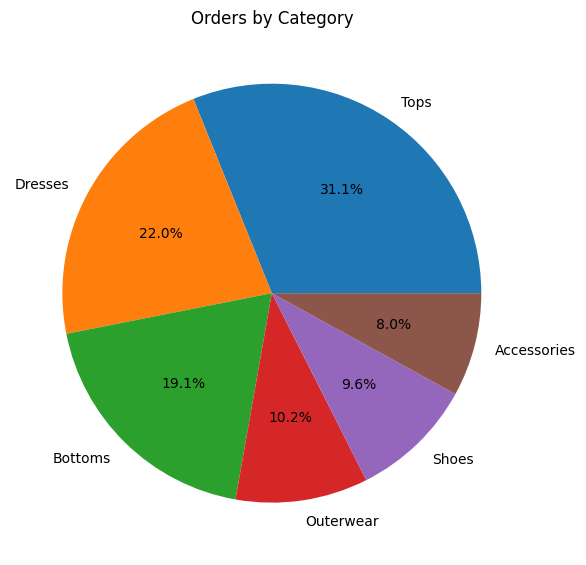

In [5]:
df["Category"].value_counts().plot(kind="pie", autopct="%1.1f%%", figsize=(6, 6))
plt.title("Orders by Category")
plt.ylabel("")
plt.tight_layout()
plt.savefig("../images/category_distribution.png", dpi=100)
plt.show()


**Insight:** "Tops" is the leading category at **31.1%** of all orders, followed by Dresses (22.0%) and Bottoms (19.1%). Demand is concentrated in a few core categories rather than spread evenly — useful for inventory and marketing prioritization.

### Q1b — What are the top 5 products by revenue?


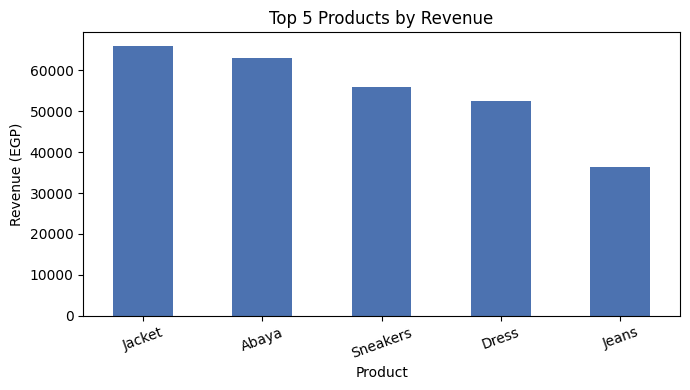

Product
Jacket      66000.0
Abaya       63000.0
Sneakers    56050.0
Dress       52500.0
Jeans       36300.0
Name: Revenue, dtype: float64

In [6]:
top_products = df.groupby("Product")["Revenue"].sum().sort_values(ascending=False)
top_products.head(5).plot(kind="bar", figsize=(7, 4), color="#4C72B0")
plt.ylabel("Revenue (EGP)")
plt.title("Top 5 Products by Revenue")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig("../images/top_products.png", dpi=100)
plt.show()

top_products.head(5)


**Insight:** unit sales are nearly flat across products (69-76 units each), so revenue ranking is driven almost entirely by price: Jacket and Abaya lead despite not being the best-selling items by quantity.


### Q2 — How did revenue trend month over month?

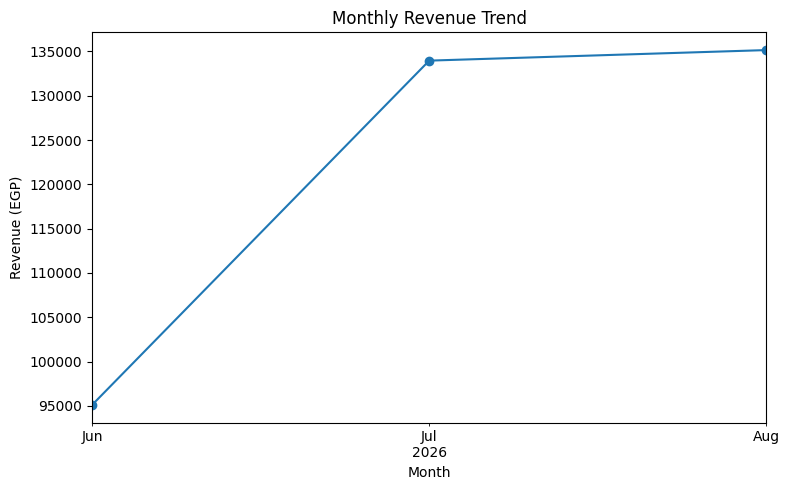

Month
2026-06     95100.0
2026-07    133960.0
2026-08    135150.0
Freq: M, Name: Revenue, dtype: float64

In [7]:
monthly_revenue = df.groupby("Month")["Revenue"].sum()

monthly_revenue.plot(kind="line", marker="o", figsize=(8, 5))
plt.xlabel("Month")
plt.ylabel("Revenue (EGP)")
plt.title("Monthly Revenue Trend")
plt.tight_layout()
plt.savefig("../images/monthly_revenue.png", dpi=100)
plt.show()

monthly_revenue


**Insight:** the dataset covers exactly three months (Jun-Aug 2026) by
design, so revenue is naturally 100% within that window once the date
parsing above is fixed. July and August are close (~134K EGP each) and
June is lower (~95K EGP) - in a real export this would be worth checking
against a full-year file rather than treated as a seasonal trend on its own.


### Q3 — Which city generates the most revenue?

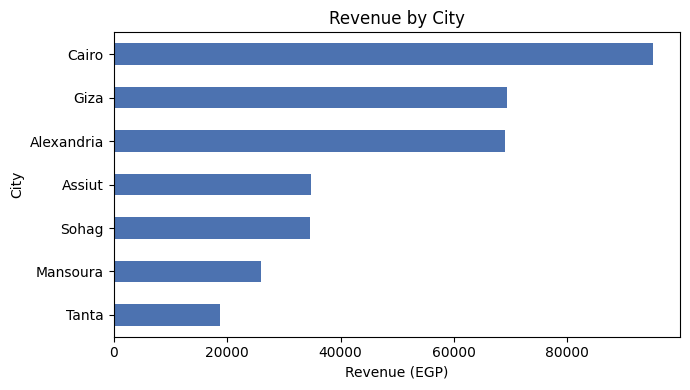

City
Cairo         95090.0
Giza          69280.0
Alexandria    68950.0
Assiut        34760.0
Sohag         34530.0
Mansoura      25970.0
Tanta         18690.0
Name: Revenue, dtype: float64

In [8]:
revenue_by_city = df.groupby("City")["Revenue"].sum().sort_values()

revenue_by_city.plot(kind="barh", figsize=(7, 4), color="#4C72B0")
plt.xlabel("Revenue (EGP)")
plt.title("Revenue by City")
plt.tight_layout()
plt.savefig("../images/revenue_by_city.png", dpi=100)
plt.show()

revenue_by_city.sort_values(ascending=False)


**Insight:** Cairo generates the highest revenue (~95K EGP) and the most
orders, followed by Giza and Alexandria. Order volume roughly tracks
population size across the seven cities in this dataset. About 4.4% of
orders have no recorded city (a genuinely blank value, not guessed) and are
excluded from this ranking - see the Cleaning Notes sheet in the Excel
report for the exact count.


### Q4 — Which payment methods do customers actually use?

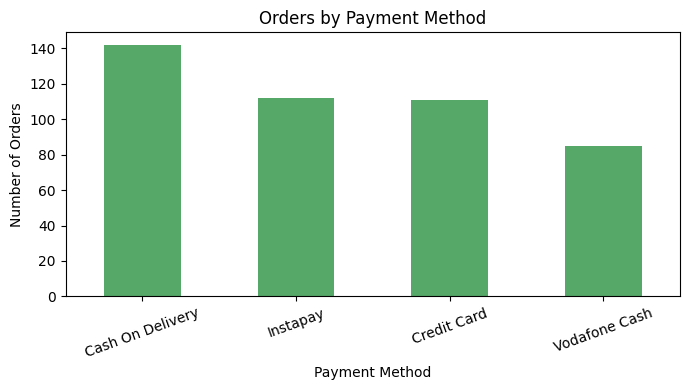

Payment Method
Cash On Delivery    31.6
Instapay            24.9
Credit Card         24.7
Vodafone Cash       18.9
Name: count, dtype: float64

In [9]:
payment_share = df["Payment Method"].value_counts()

payment_share.plot(kind="bar", figsize=(7, 4), color="#55A868")
plt.ylabel("Number of Orders")
plt.title("Orders by Payment Method")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig("../images/payment_methods.png", dpi=100)
plt.show()

(payment_share / payment_share.sum() * 100).round(1)


**Insight:** Cash on Delivery is still the leading payment method
(~32%), with Instapay and Credit Card close behind (~25% each). This means
roughly two-thirds of orders now use a digital/pre-paid method — useful for
the business to know if it's deciding where to invest in payment UX.

### Q5 — What share of orders are cancelled or returned?

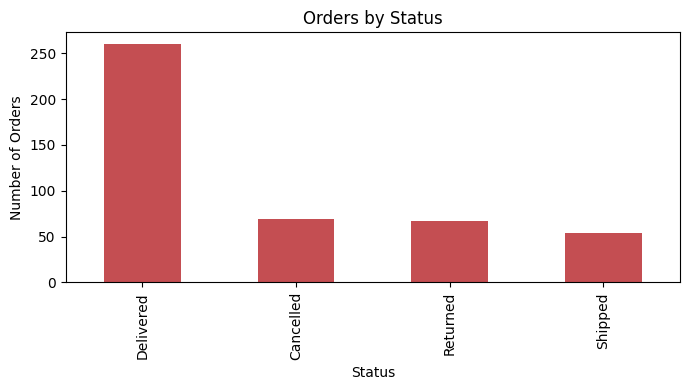

Status
Delivered    57.8
Cancelled    15.3
Returned     14.9
Shipped      12.0
Name: count, dtype: float64

In [10]:
status_counts = df["Status"].value_counts()

status_counts.plot(kind="bar", figsize=(7, 4), color="#C44E52")
plt.ylabel("Number of Orders")
plt.title("Orders by Status")
plt.tight_layout()
plt.savefig("../images/order_status.png", dpi=100)
plt.show()

(status_counts / status_counts.sum() * 100).round(1)


**Insight:** About **15% of orders are cancelled and 15% are returned**
— together, nearly a third of all orders never convert into a kept sale.
That's a strong signal to dig further into *why* (payment method?
product category? city?) before treating the revenue totals above as final,
realized revenue.

## 4. Save the cleaned dataset

In [11]:
df.to_csv("../data/cleaned/cleaned_sales_data.csv", index=False)
print("Saved:", len(df), "rows to data/cleaned/cleaned_sales_data.csv")


Saved: 450 rows to data/cleaned/cleaned_sales_data.csv


## 4b. Build the client-facing Excel report

Same numbers as above, laid out as the three-sheet report delivered to the client (`Report`, `Cleaned Data`, `Cleaning Notes`), with live Excel formulas so it recalculates if the data changes.


In [12]:
from report import build_excel_report

build_excel_report(df, raw, "../reports/cleaned_sales_report.xlsx")
print("Saved: reports/cleaned_sales_report.xlsx")


Saved: reports/cleaned_sales_report.xlsx


## 5. Limitations & Future Work

- **Missing data was not imputed.** ~5% of `City`, `Qty`, and `Price` values
  are genuinely unknown and were left as `NaN` rather than guessed, so any
  totals in this notebook are slightly understated, not wrong.
- The revenue spike in Jun–Aug should be confirmed against the source system
  rather than assumed to be a real seasonal pattern.
- **Next step:** join this cleaned data with SQL for deeper relational
  analysis (Project 2), and later build a model to predict which orders are
  likely to be cancelled or returned (Project 3/4).
